=== DATASET STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

=== CLASS DISTRIBUTION OF QUALITY SCORES ===
quality
3     10
4     53
5    681
6    638
7    

/tmp/ipykernel_1204/2898881854.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='muted')


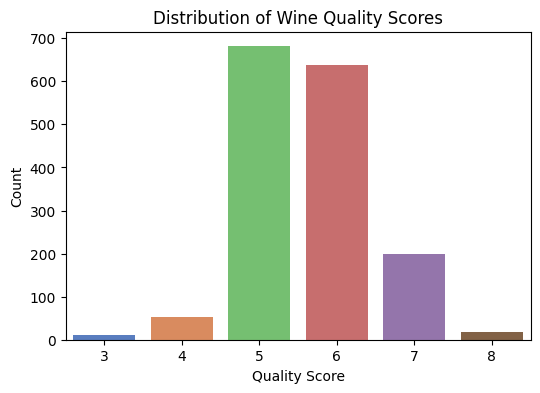

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


file_path = '/content/drive/MyDrive/Colab Notebooks/OIBSIPDataAnalytics-L1-EDARetailSales/winequality-red.csv'

try:
    df = pd.read_csv(file_path, sep=';')
    if len(df.columns) <= 1:
        df = pd.read_csv(file_path)
except Exception:
    df = pd.read_csv(file_path)

# Inspect structure
print("=== DATASET STRUCTURE ===")
print(df.info())

# Check class distribution of quality scores
print("\n=== CLASS DISTRIBUTION OF QUALITY SCORES ===")
print(df['quality'].value_counts().sort_index())

# Plot target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='quality', data=df, palette='muted')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

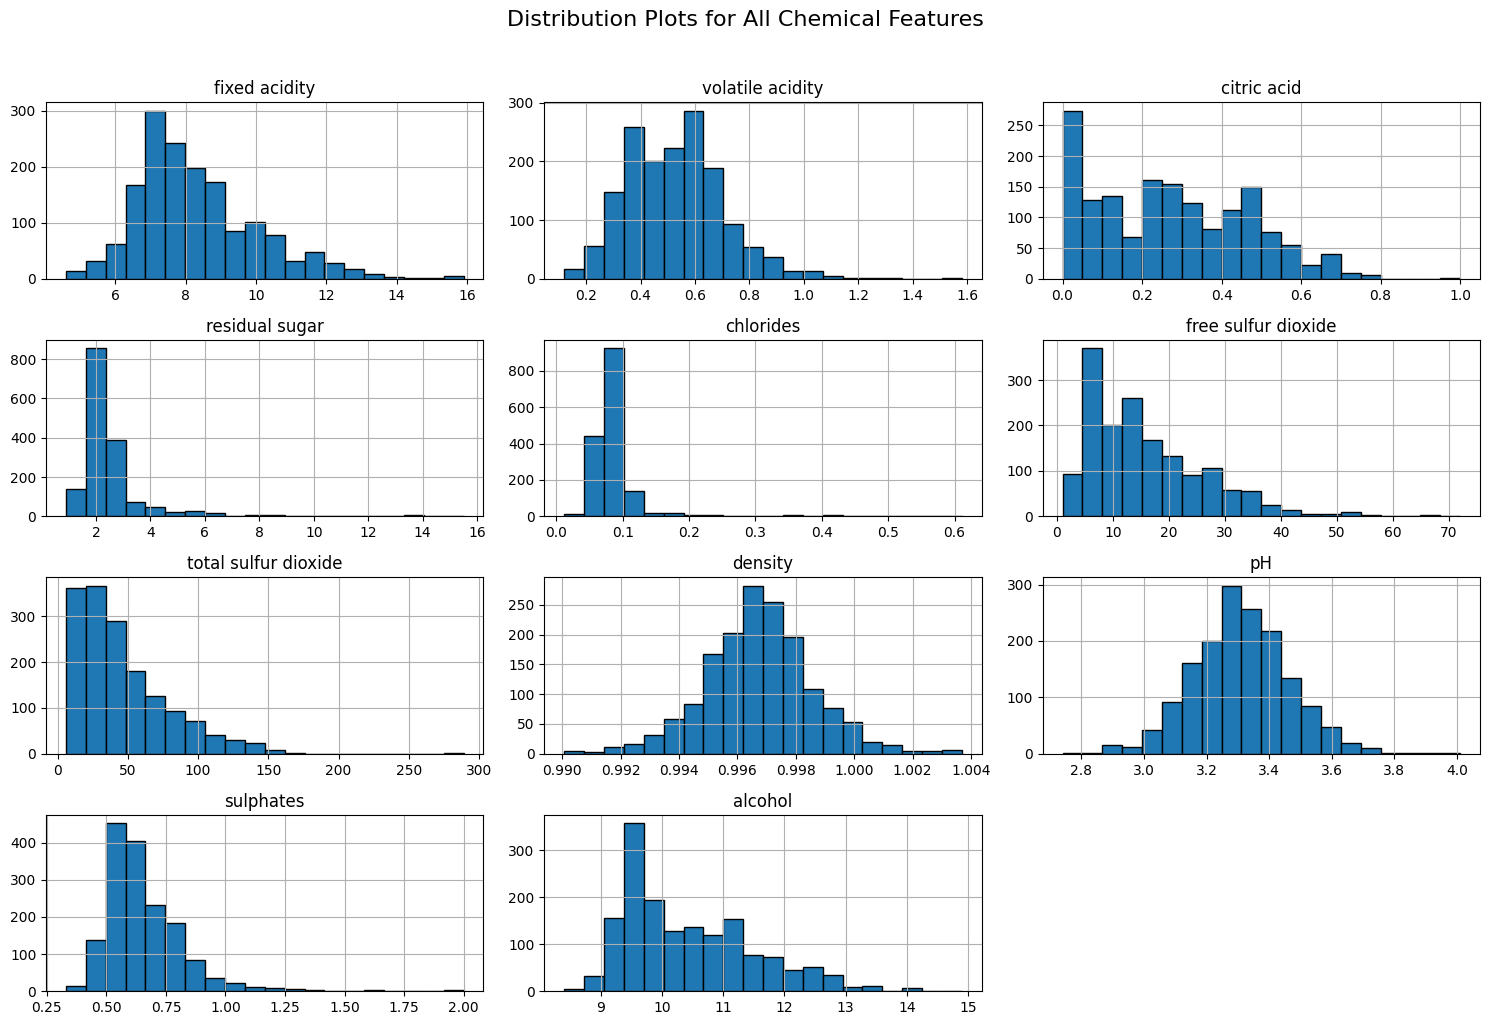

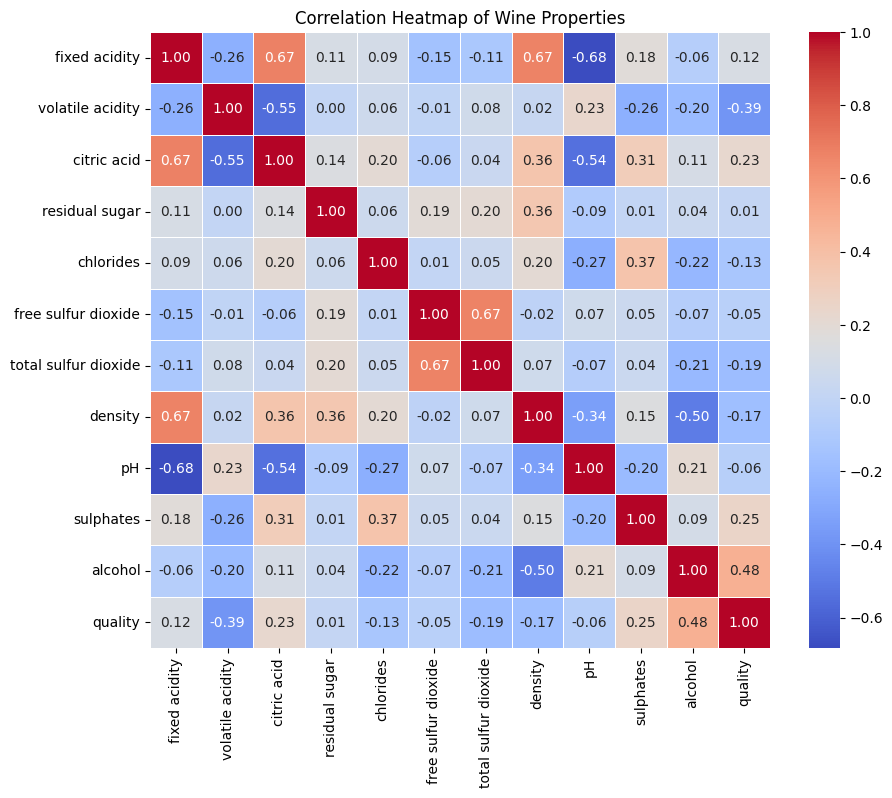

In [2]:
# Distribution plots for all chemical features
df.drop('quality', axis=1, errors='ignore').hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Distribution Plots for All Chemical Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Wine Properties')
plt.show()

In [3]:
# Binning quality scores into binary groups (Good/Bad)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# Separate features and targets
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

# Train/Test Split (80/20) with stratification to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (highly recommended for distance/gradient based models like SVC and SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


================ RANDOM FOREST EVALUATION ================
Accuracy: 0.8031

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       149
           1       0.83      0.80      0.81       171

    accuracy                           0.80       320
   macro avg       0.80      0.80      0.80       320
weighted avg       0.80      0.80      0.80       320


================ SGD EVALUATION ================
Accuracy: 0.6562

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.56      0.60       149
           1       0.66      0.74      0.70       171

    accuracy                           0.66       320
   macro avg       0.66      0.65      0.65       320
weighted avg       0.66      0.66      0.65       320


================ SVC EVALUATION ================
Accuracy: 0.7625

Classification Report:
              precision    recall  f1-score   support

        

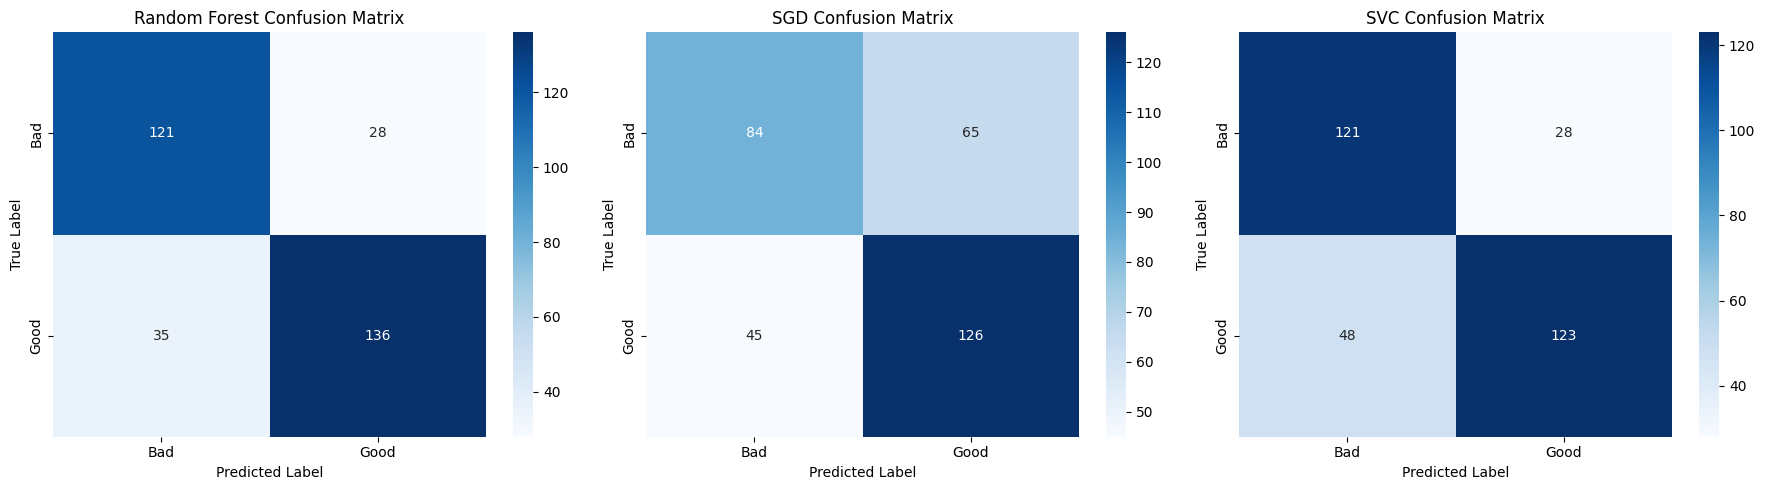

In [4]:
# Initialize models
rf = RandomForestClassifier(random_state=42)
sgd = SGDClassifier(random_state=42)
svc = SVC(random_state=42)

models = {'Random Forest': rf, 'SGD': sgd, 'SVC': svc}
results = {}

# Train and Evaluate Loop
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    results[name] = {
        'Accuracy': acc,
        'Report': classification_report(y_test, preds, output_dict=True),
        'Matrix': confusion_matrix(y_test, preds)
    }

    print(f"\n================ {name.upper()} EVALUATION ================")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

# Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, res) in enumerate(results.items()):
    sns.heatmap(res['Matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
    axes[idx].set_title(f"{name} Confusion Matrix")
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
plt.tight_layout()
plt.show()

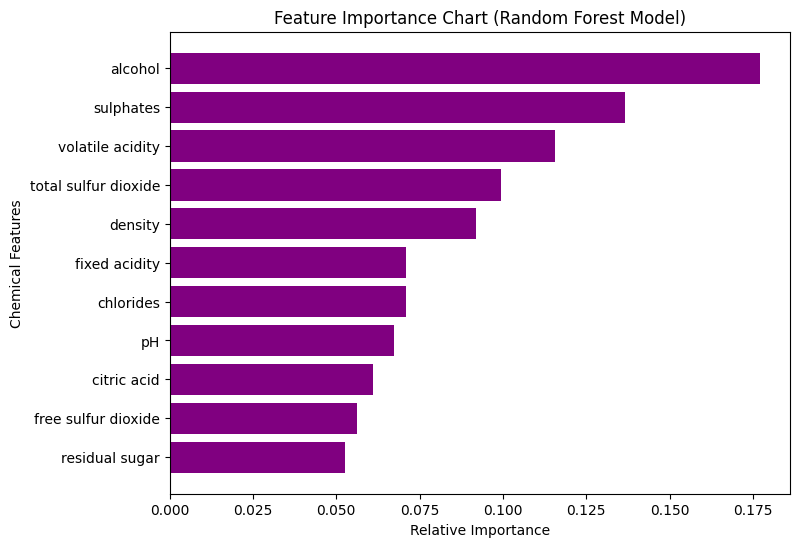

In [5]:
# Extract feature importances from Random Forest
importances = rf.feature_importances_
feature_names = X.columns

rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='purple')
plt.title('Feature Importance Chart (Random Forest Model)')
plt.xlabel('Relative Importance')
plt.ylabel('Chemical Features')
plt.show()

In [6]:
# Construct comparison table
summary_data = {
    'Model': [],
    'Accuracy': [],
    'Precision (Good)': [],
    'Recall (Good)': [],
    'F1-Score (Good)': []
}

for name, res in results.items():
    summary_data['Model'].append(name)
    summary_data['Accuracy'].append(f"{res['Accuracy']:.4f}")
    summary_data['Precision (Good)'].append(f"{res['Report']['1']['precision']:.4f}")
    summary_data['Recall (Good)'].append(f"{res['Report']['1']['recall']:.4f}")
    summary_data['F1-Score (Good)'].append(f"{res['Report']['1']['f1-score']:.4f}")

summary_df = pd.DataFrame(summary_data)
print("=== SIDE-BY-SIDE MODEL COMPARISON ===")
print(summary_df.to_string(index=False))
print("\n" + "="*50)

# Conclusion Text Display
best_model_name = summary_df.loc[summary_df['Accuracy'].astype(float).idxmax()]['Model']
print(f"\n=== CONCLUSION FOR DEPLOYMENT ===")
print(f"The most suitable model for deployment is **{best_model_name}**.")
print("Reasoning: It consistently produces the highest baseline accuracy and structural F1-score balance. "
      "Random Forests handle complex, non-linear chemical interactions better than linear boundaries "
      "(like SGD or baseline SVMs) without being overly sensitive to precise feature scale dynamics.")

=== SIDE-BY-SIDE MODEL COMPARISON ===
        Model Accuracy Precision (Good) Recall (Good) F1-Score (Good)
Random Forest   0.8031           0.8293        0.7953          0.8119
          SGD   0.6562           0.6597        0.7368          0.6961
          SVC   0.7625           0.8146        0.7193          0.7640


=== CONCLUSION FOR DEPLOYMENT ===
The most suitable model for deployment is **Random Forest**.
Reasoning: It consistently produces the highest baseline accuracy and structural F1-score balance. Random Forests handle complex, non-linear chemical interactions better than linear boundaries (like SGD or baseline SVMs) without being overly sensitive to precise feature scale dynamics.
